# Module Four Activity

For the module four assignment you are not required to produce or submit any coding samples. This Notebook is provided with the sample code that were used to create the visualizations you will be reviewing as part of your assignment, feel free to explore the code if desired.

The data used to create the visualization is located in the following path <b><mark>'data/formated_tabn333.30.csv'</mark></b>

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> Use the following three visualizations to complete your assignment.</span>
</div>

You must address the following rubric criteria: 

1. Describe how each visualization represents the data.  

2. Describe the key characteristics of each visualization. Include the following:  

- Chart type 

- Layout 

- Labeling 

3. Compare the visualizations by analyzing how effectively each one communicates the data set’s insights. Include the following: 

- Clarity 

- Data type alignment 

4. Evaluate which visualization is most appropriate for the given audience. Include the following:  

- A rationale for your selection.  

5. Recommend multiple refinements to any of the visualizations provided. Include the following:  

- A justification of how the refinements would better suit the audience’s needs.  

 

## Technical Visualization:
<img src='output/technical_viz.png'>

## Simple Visualization:
<img src='output/simple_viz.png'>

## Story Visualization:
<img src='output/story_viz.png'>

## Installing Required Packages
The requirements.txt file is empty here, but maintained in the event you would like to add some packages for exploration.

In [5]:
!pip install -r requirements.txt

## Import the Required Packages

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import Image, display

# Initial Data Cleaning
This first section of the Notebook cleans and prepares the original data source for later visualization implementation.

The following blocks take in the tabn333.30.xslx file and convert it to a CSV file that has the Column with States and \<year range\>. The original excel file has it formatted as States on the left column and \<year-ranges\> as the top row heading.

## Loading the Data
This loads the original data, skipping the title rows

In [7]:
df = pd.read_csv('data/tabn333.30.csv', skiprows=2)

## Cleaning the Data

In [8]:
def transform_data(df):
    # Remove 'United States' and any summary rows
    df = df[~df.iloc[:, 0].str.contains('United States', na=False, regex=True)]
    
    # Get state appropriations columns only (skip local appropriations)
    state_df = df.iloc[:, :6]  # First 6 columns for state appropriations
    
    # Clean column names
    state_df.columns = ['State', '1990-91', '2000-01', '2010-11', '2019-20', '2020-21']
    
    # Remove any rows with NaN in State column and clean up state names
    state_df = state_df.dropna(subset=['State'])
    state_df['State'] = state_df['State'].str.strip()
    
    # Convert numeric values to integers
    for col in state_df.columns[1:]:
        state_df[col] = pd.to_numeric(state_df[col], errors='coerce')
        state_df[col] = state_df[col].fillna(0).astype(int)
    
    # Create dictionary format
    result_dict = {
        'State': state_df['State'].tolist(),
        '1990-91': state_df['1990-91'].tolist(),
        '2000-01': state_df['2000-01'].tolist(),
        '2010-11': state_df['2010-11'].tolist(),
        '2019-20': state_df['2019-20'].tolist(),
        '2020-21': state_df['2020-21'].tolist()
    }
    
    # Convert to DataFrame
    result_df = pd.DataFrame(result_dict)
    
    return result_df

# Transform the data
transformed_df = transform_data(df)

# Save as CSV
transformed_df.to_csv('data/formatted_tabn333.30.csv', index=False)

In [9]:
print("Data format:")
print(transformed_df.to_dict())
print("\nFirst few rows:")
print(transformed_df.head())
print("\nData has been saved to 'data/formatted_tabn333.30.csv'")

Data format:
{'State': {0: 'State or jurisdiction', 1: '1', 2: 'Alabama', 3: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California', 7: 'Colorado', 8: 'Connecticut', 9: 'Delaware', 10: 'District of Columbia', 11: 'Florida', 12: 'Georgia', 13: 'Hawaii', 14: 'Idaho', 15: 'Illinois', 16: 'Indiana', 17: 'Iowa', 18: 'Kansas', 19: 'Kentucky', 20: 'Louisiana', 21: 'Maine', 22: 'Maryland', 23: 'Massachusetts', 24: 'Michigan', 25: 'Minnesota', 26: 'Mississippi', 27: 'Missouri', 28: 'Montana', 29: 'Nebraska', 30: 'Nevada', 31: 'New Hampshire', 32: 'New Jersey', 33: 'New Mexico', 34: 'New York', 35: 'North Carolina', 36: 'North Dakota', 37: 'Ohio', 38: 'Oklahoma', 39: 'Oregon', 40: 'Pennsylvania', 41: 'Rhode Island', 42: 'South Carolina', 43: 'South Dakota', 44: 'Tennessee', 45: 'Texas', 46: 'Utah', 47: 'Vermont', 48: 'Virginia', 49: 'Washington', 50: 'West Virginia', 51: 'Wisconsin', 52: 'Wyoming', 53: 'U.S. Service Academies', 54: 'Other jurisdictions', 55: 'American Samoa', 56: 'Federated Stat

# Generating the Visualizations
The following blocks read the formatted_tab333.30.csv file and generates 3 distinct visual diagrams. It can use sample data to do this as well.

## Loading the Data
Based on the use_csv toggle, will load the data from the csv or the sample code.

### Data Source Information
The sourcing information for the data can be found in the `README.md` file within the data folder.

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> toggle the flag <mark>use_csv</mark> boolean variable as desired. Set to True to use the <b><mark>formatted_tab333.30.csv</mark></b> file, and False to use the <b><mark>sample_data</mark></b>.</span>
</div>

Note that this code is starting with the original formatted data provided and not explicitly dependent on the previous cleaning steps. If you would like testing the code against your version of the clean data output process, you will need to change the csv file path.

In [10]:
use_csv = False

if use_csv:
    # Read the CSV file
    try:
        df = pd.read_csv('data/formatted_tabn333.30.csv')
        print("Successfully loaded CSV data")
        
        # Clean the data: Remove any non-numeric values and convert to numeric
        for column in df.columns:
            if column != 'State':
                df[column] = pd.to_numeric(df[column], errors='coerce')
        
        # Remove rows with all NaN values in numeric columns
        df = df.dropna(subset=[col for col in df.columns if col != 'State'], how='all')
        
    except FileNotFoundError:
        print("Error: CSV file not found. Switching to sample data.")
        use_csv = False

if not use_csv:
    # Sample data code remains the same
    sample_data = {
        'State': ['California', 'New York', 'Texas', 'Florida', 'Illinois', 
                  'Pennsylvania', 'Ohio', 'Michigan', 'Georgia', 'North Carolina'],
        '1990-91': [8500, 9200, 7800, 6500, 8900, 7600, 7200, 7800, 6900, 8100],
        '2000-01': [9200, 9800, 8400, 7200, 9300, 8100, 7800, 8200, 7500, 8800],
        '2010-11': [6800, 8500, 7900, 6800, 8500, 7400, 6900, 7100, 7200, 8400],
        '2015-16': [7500, 9100, 8200, 7100, 8800, 7600, 7100, 7400, 7600, 8900],
        '2019-20': [8900, 9600, 8600, 7400, 9100, 7900, 7300, 7600, 8100, 9200],
        '2020-21': [9500, 10200, 9100, 7800, 9400, 8200, 7500, 7900, 8400, 9500]
    }
    df = pd.DataFrame(sample_data)
    print("Using sample data")

Using sample data


## Get numeric columns (years)

In [11]:
years = [col for col in df.columns if col != 'State' and col != 'Percent_Change']

print("\nData columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())


Data columns: ['State', '1990-91', '2000-01', '2010-11', '2015-16', '2019-20', '2020-21']

First few rows:
        State  1990-91  2000-01  2010-11  2015-16  2019-20  2020-21
0  California     8500     9200     6800     7500     8900     9500
1    New York     9200     9800     8500     9100     9600    10200
2       Texas     7800     8400     7900     8200     8600     9100
3     Florida     6500     7200     6800     7100     7400     7800
4    Illinois     8900     9300     8500     8800     9100     9400


### 1. Technical Visualization: Time Series Analysis
To prevent the overwriting of the visualizations provided, the output path is set to an alternate location from the originals.

In [12]:
plt.figure(figsize=(15, 8))
selected_states = ['California', 'New York', 'Texas', 'Florida', 'Illinois']
for state in selected_states:
    if state in df['State'].values:
        state_data = df[df['State'] == state]
        plt.plot(years, state_data[years].iloc[0], 
                marker='o', linewidth=2, label=state)

plt.title('30-Year Trend of State Appropriations for Higher Education\nBy Selected States')
plt.xlabel('Academic Year')
plt.ylabel('Appropriations per FTE Student ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('output/technical_viz.png')
plt.close()

#### Technical Visualization Image Rendering

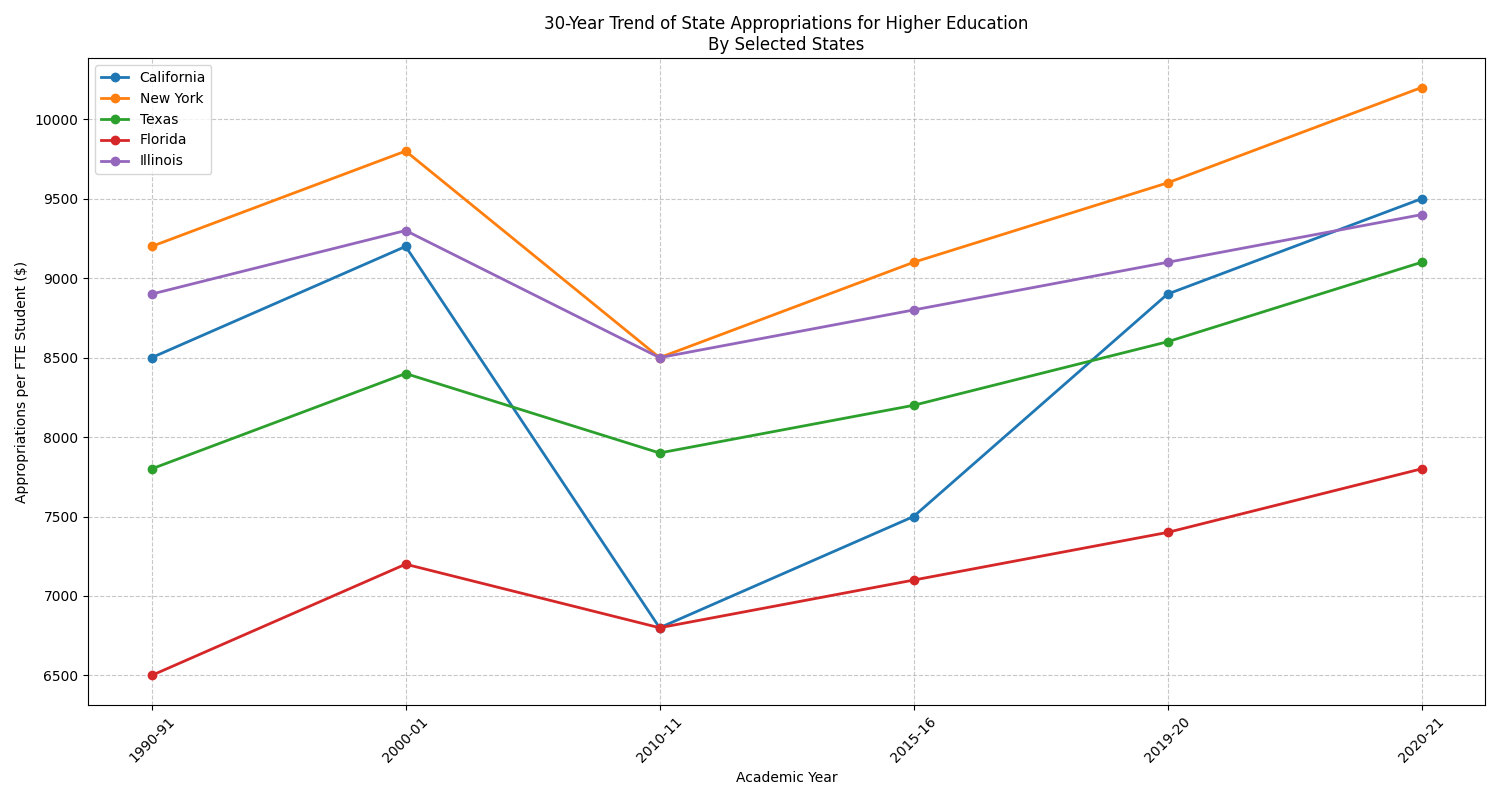

In [13]:
display(Image('output/technical_viz.png'))

### 2. Simple Bar Chart: Current Year Comparison
To prevent the overwriting of the visualizations provided, the output path is set to an alternate location from the originals.

In [14]:
plt.figure(figsize=(12, 6))
current_year = years[-1]  # Get the last year from the data

# Create the bar chart
x = np.arange(len(df['State']))  # Create numeric x-coordinates
plt.bar(x, df[current_year].astype(float), color='skyblue')

# Add the mean line
mean_value = df[current_year].astype(float).mean()
plt.axhline(y=mean_value,
            color='red',
            linestyle='--',
            label=f'National Average (${mean_value:,.0f})')

# Set the x-axis labels
plt.xticks(x, df['State'], rotation=45, ha='right')
plt.xlabel('States')
plt.ylabel('Appropriations per FTE Student ($)')
plt.title(f'State Higher Education Funding\n{current_year}')
plt.legend()
plt.tight_layout()
plt.savefig('output/simple_viz.png')
plt.close()

#### Simple Visualization Image Rendering

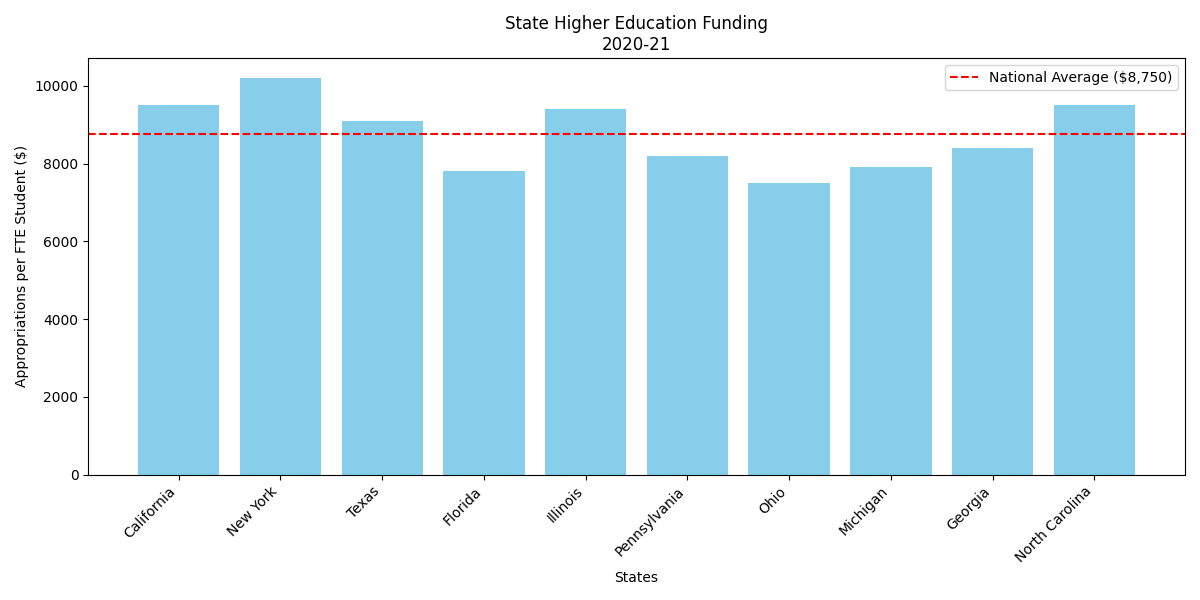

In [15]:
display(Image('output/simple_viz.png'))

### 3. Story-telling Visualization: Change Over Time
To prevent the overwriting of the visualizations provided, the output path is set to an alternate location from the originals.

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Top panel: Percent change from first to last year
first_year = years[0]
last_year = years[-1]

# Calculate percent change using numeric values
df['Percent_Change'] = ((df[last_year].astype(float) - df[first_year].astype(float)) / 
                       df[first_year].astype(float) * 100)

# Sort and create x positions
df_sorted = df.sort_values('Percent_Change', ascending=True)
x_pos = np.arange(len(df_sorted))

# Create colors array
colors = ['red' if x < 0 else 'green' for x in df_sorted['Percent_Change']]

# Create horizontal bar chart
ax1.barh(x_pos, df_sorted['Percent_Change'].astype(float), color=colors)

# Set y-tick labels
ax1.set_yticks(x_pos)
ax1.set_yticklabels(df_sorted['State'])

ax1.set_title(f'Percent Change in State Appropriations\n({first_year} to {last_year})')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Percent Change')

# Bottom panel: Box plot showing distribution over time
box_data = [df[year].astype(float).dropna() for year in years]
ax2.boxplot(box_data, labels=years)
ax2.set_title('Distribution of State Appropriations Over Time')
ax2.set_xticklabels(years, rotation=45)
ax2.set_ylabel('Appropriations per FTE Student ($)')

plt.tight_layout()
plt.savefig('output/story_viz.png')
plt.close()

/tmp/ipykernel_10633/1378744229.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(box_data, labels=years)


#### Simple Visualization Image Rendering

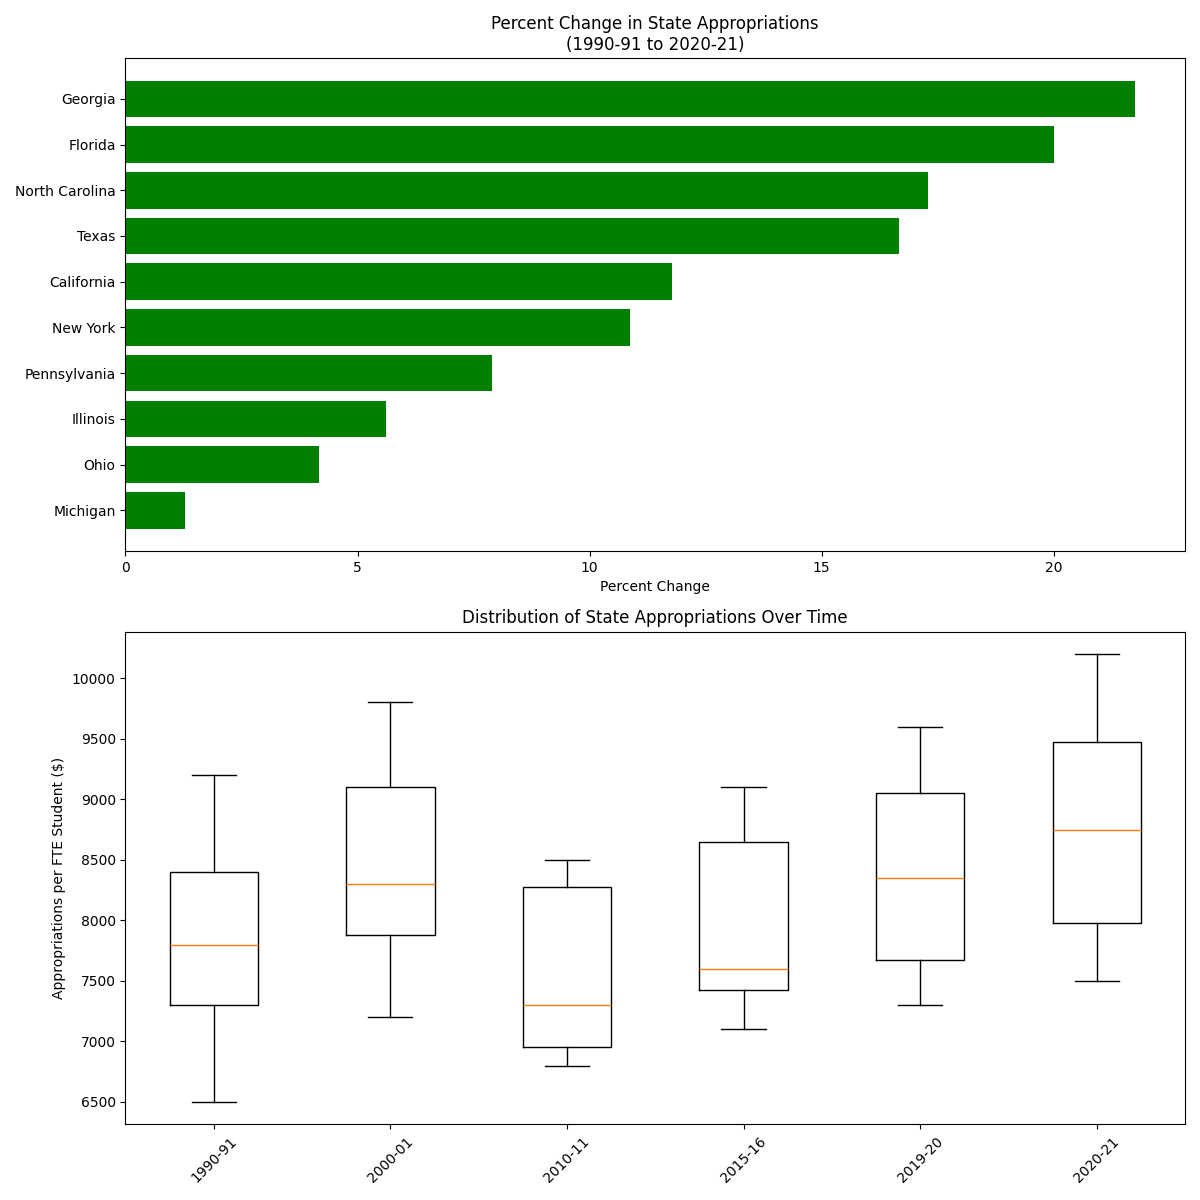

In [17]:
display(Image('output/story_viz.png'))

### Visualizations Complete

In [18]:
print("\nThree visualizations have been generated and saved:")
print("1. technical_viz.png - Time series analysis")
print("2. simple_viz.png - Current year comparison")
print("3. story_viz.png - Historical change analysis")


Three visualizations have been generated and saved:
1. technical_viz.png - Time series analysis
2. simple_viz.png - Current year comparison
3. story_viz.png - Historical change analysis
